# MOD510: Project 4

**Deadline: 01. December 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1: Stochastic modeling of mixing tanks


## Part 1: Single Mixing Tank with Parameter Uncertainty 

### Task 1 - Derivation of the concentration in a single mixing tank

We concider a well-mixed tank with constant volume $V$, inflow rate $Q_{in}$, outflow rate $Q_{out}$ and constant inflow concentration $C_{in}$.

To determine the solute concentration in the tank, $C(t)$, the following governing differential equation must be solved: 


$$\frac{dC}{dt} = \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C.$$

The governing differential equation is a first-order linear ordinary differential equation of the form

$$\frac{dC}{dt} + P(t)C = Q(t),$$

with

$$P(t) = \frac{Q_{out}}{V}, \quad  \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

where $P$ and $Q$ are constants, since the system parameters do not vary with time.

**Integrating factor**

The integrating factor of a first-order linear ODE is defined as

$$I(t) = e^{\int P(t) \text{ dt}}.$$

For readability, we will write the exponential function using the notation $\exp(\space)$:

$$I(t) = \exp\left(\int P(t) \text{ dt}\right).$$

Substituting $P(t) = \frac{Q_{out}}{V}$, we obtain

$$I(t) = \exp\left(\int \frac{Q_{out}}{V} \text{ dt}\right) \quad \Rightarrow \quad I(t) = \exp\left(\frac{Q_{out}}{V}t\right)$$

Using the integrating factor $I(t)$, the solution of the first-order linear ODE can be written as

$$C(t) = \frac{1}{I(t)}\left( \int I(t) Q(t) \text{ dt} + K\right),$$

where $K$ is an integration constant. 

Substituting 

$$I(t) = \exp\left(\frac{Q_{out}}{V}t\right), \quad \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

gives

$$C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right).$$

This can be rewritten as

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right)$$

Evaluating the integral yields:

$$\int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} = \frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K$$

Substituting back, we obtain

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K \right)$$

This simplifies to

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{Q_{out}} C_{in} + K \right)$$

Multiplying through gives

$$C(t) = K\exp\left(-\frac{Q_{out}}{V}t\right) + \frac{Q_{in}}{Q_{out}} C_{in}$$

Finally, the solution is

$$\boxed{C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in} }$$

### Task 2 - Analytical solution with average parameters

Using the average parameter values

$$V = 1000 \text{ L} \quad Q_{out} = 100 \text{ L/s} \quad Q_{in} = 100 \text{ L/s} \quad C_{in} = 0.25 \text{ g/L} \quad C(0) = 3.5 \text{ g/L},$$

the general solution from Task $1$, 

$$C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in}$$

becomes

$$ C(t) =  K e^{- \frac{100 \text{ L/s}}{1000 \text{ L}} t} + \frac{100 \text{ L/s}}{100 \text{ L/s}} \cdot 0.25 \text{ g/L}. $$

Which simplifies to 

$$C(t) = K e^{-0.1 \text{ s}^{-1}t} + 0.25 \text{ g/L}$$

To find $K$, we apply the initial condition $C(0) = 3.5$ g/L:

$$K e^{0} + 0.25 \text{ g/L} = 3.5 \text{ g/L} \quad \Rightarrow \quad K = 3.5\text{ g/L} - 0.25 \text{ g/L} \quad \Rightarrow \quad K = 3.25\text{ g/L}$$

With $t$ measured in seconds, the concentration $C(t)$ in g/L is therefore

$$\boxed{C(t)= 3.25 \cdot e^{-0.1t} + 0.25}$$

The concentration decreases exponentially from the initial value $3.5$ g/L towards the steady-state value $0.25$ g/L. 

### Task 3 - Probabilistic interpretation of outflow

The probabilitiy that a gram of solute leaves the tank during a time interval $\Delta t$ is 

$$p = 1 - e^{-\frac{Q_{out}}{V} \Delta t}.$$

**Interpretation:**
\begin{align*}
1 - p = & \text{ probability that a gram of solute remains in the tank.}\\
p = & \text{ probability that a gram of solute leaves the tank.} 
\end{align*}


This gives the following update for the concentration:

$$\boxed{C(t + \Delta t) = (1 - p)C(t) + pC_{in}}$$

**Broken down:**
\begin{align*}
(1 - p)C(t) = & \text{ portion of the old concentration that remains in the tank.}\\
pC_{in} = & \text{ portion that is replaced by fresh inflow.} 
\end{align*}

This shows that the updated concentration depends on how much of the old solution remains and how much fresh solution enters, controlled by the probabillity of solute leaving during the time interval. 

### Task 4 - Monte Carlo Simulation with Fixed Parameters

To make the simulation structured and reusable, the Monte Carlo procedure is implemented as a function. This function allows switching between fixed parameters per run and parameters that vary at each time step through a Boolean input `fixed_parameters`, making it straightforward to compare the two modelling options. 

After defining the function, the simulation setting are specified and the Monte Carlo simulation is executed for Option $1$. Here, the parameters are kept fixed within each run.

$$\textcolor{red}{\text{Rewrite only about how the function works and that it  has been created so that is avoid code repetiotion through out Exercise 1}}$$

$$\textcolor{red}{\text{Write about the statistics and how they are calculated}}$$

In [1]:
import numpy as np
from numpy import random as rnd

#For reproducibility
rnd.seed(18)

def monte_carlo_simulation(t0, tf, n_runs, n_steps, fixed_parameters = True, n_tanks = 1, c_in = 0.0):
    '''
    Monte Carlo simulation of concentration evolution in a mixing tank.

    Input
    ------
    t0: float
        Start time [s].
    tf: float
        Final time [s].
    n_runs: int
        Number of Monte Carlo runs.
    n_steps: int
        Number of time steps per run.
    fixed_parameters: bool
        If True, parameters are fixed per run.
        If False, parameters vary at each time step.
    n_tanks: int
        Number of tanks.
    c_in: float
        Solute concentration of the inflow.

    Output
    ------
    c_mean: ndarray (shape = (n_tanks, n_steps)
        Mean concentration over runs.
    c_std: ndarray (shape = (n_tanks, n_steps)
        Standard deviation over runs.
    ci_lower: ndarray (shape = (n_tanks, n_steps)
        Lower bound of the 95% confidence interval.
    ci_upper: ndarray (shape = (n_tanks, n_steps)
        Upper bound of the 95% confidence interval.
    '''
    #Delta time
    dt = (tf - t0) / n_steps

    #Allocate concentration history
    concentration = np.zeros((n_tanks, n_runs, n_steps))

    #Monte Carlo simulation
    for run in range(n_runs):
        v = rnd.uniform(950, 1050)
        c = np.zeros(n_tanks)

        #Initial concentration
        c[0] = rnd.uniform(3.4, 3.6)
        c[1:] = rnd.uniform(0, 0.1, size = n_tanks - 1)

        if fixed_parameters:
            q_out = q_in = rnd.uniform(95, 105)

        for t in range(n_steps):
            if not fixed_parameters:
                q_out = q_in = rnd.uniform(95, 105)

            p = 1 - np.exp((-q_out / v) * dt)

            #Update tanks
            for n in range(n_tanks):
                inflow = c_in if n == 0 else c[n-1]
                c[n] = c[n] * (1 - p) + inflow * p

            concentration[:, run, t] = c

    #Mean concentration across runs
    c_mean = np.mean(concentration, axis = 1)

    #Standard deviation
    c_std = np.std(concentration, axis = 1)

    #95% confidence intervals
    ci_lower = c_mean - 1.960 * (c_std / np.sqrt(n_runs))
    ci_upper = c_mean + 1.960 * (c_std / np.sqrt(n_runs))

    return c_mean, c_std, ci_lower, ci_upper

$$\textcolor{red}{\text{Write about fixed parameter how we coded it and how it works. What do we expect?}}$$

In [2]:
#Simulation settings (100s simulated with 1000 timesteps)
n_particles = 100
n_steps = 1000
t_start = 0
t_final = 100

#For task 4: Fixed parameter per run
fixed_parameters = True

#Perform Monte Carlo simulation
(c_mean_op1,
 c_std_op1,
 ci_lower_op1,
 ci_upper_op1
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

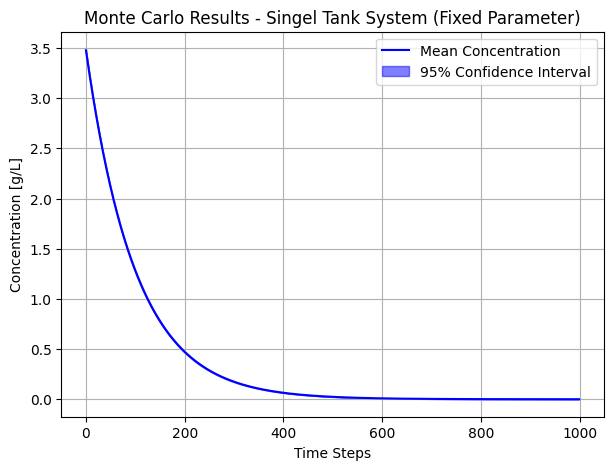

In [3]:
#Plotting the result
import matplotlib.pyplot as plt
time_steps = np.arange(n_steps)
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_op1[0], color = 'blue',label = 'Mean Concentration')
plt.fill_between(time_steps, ci_lower_op1[0], ci_upper_op1[0], alpha = 0.5, color = 'blue', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Results - Singel Tank System (Fixed Parameter)')
plt.grid()
plt.show()


$$\textcolor{red}{\text{Discuss result. Was it as expected?}}$$

The concentration decays exponentially towards zero, with the confidence interval being smallest at the start and end of the simulation and largest near the "elbow" of the curve. A detailed comparison of both options is given in Task $5$.

### Task 5 - Monte Carlo Simulation with Time-Varying Parameters

In this task, the Monte Carlo simulation is repeated with parameters fluctuating at every time step. This is a achived by setting the Boolean value `fixed_parameters` to `False`, causing new values of $Q_{in} = Q_{out}$ to be resamples from the uniform distribution at each time step. 

$$\textcolor{red}{\text{Write about fixed parameter how we coded it and how it works. What do we expect?}}$$

In [4]:
#For task 5: Parameters vary at each time step
fixed_parameters = False

#Perform Monte Carlo simulation with same settings as Task 4
(c_mean_op2,
 c_std_op2,
 ci_lower_op2,
 ci_upper_op2
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

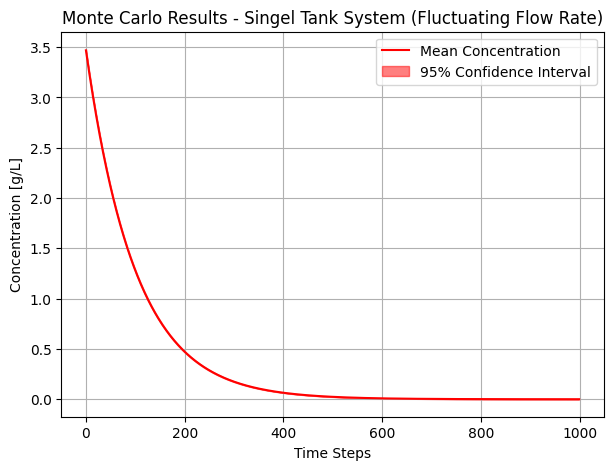

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_op2[0], color = 'red', label = 'Mean Concentration')
plt.fill_between(time_steps, ci_lower_op2[0], ci_upper_op2[0], alpha = 0.5, color = 'red', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Results - Singel Tank System (Fluctuating Flow Rate)')
plt.grid()
plt.show()

$$\textcolor{red}{\text{Discuss result. Was it as expected?}}$$

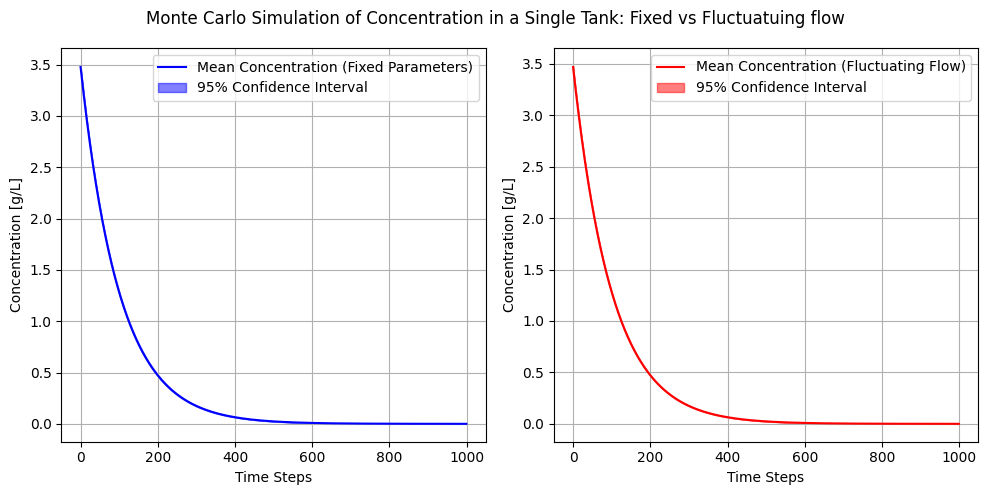

In [6]:
import matplotlib.pyplot as plt
#time = np.linspace(t_start, t_final, n_steps)
time_steps = np.arange(n_steps)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(time_steps, c_mean_op1[0], color = 'blue',label = 'Mean Concentration (Fixed Parameters)')
plt.fill_between(time_steps, ci_lower_op1[0], ci_upper_op1[0], alpha=0.5, color = 'blue', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.subplot(1, 2, 2)
plt.plot(time_steps, c_mean_op2[0], color = 'red', label = 'Mean Concentration (Fluctuating Flow)')
plt.fill_between(time_steps, ci_lower_op2[0], ci_upper_op2[0], alpha=0.5, color = 'red', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.suptitle('Monte Carlo Simulation of Concentration in a Single Tank: Fixed vs Fluctuatuing flow')
plt.tight_layout()
plt.show()


$$\textcolor{red}{\text{Compare the two. What is different, and why?}}$$

In [7]:
width_op1 = ci_upper_op1[0] - ci_lower_op1[0]
width_op2 = ci_upper_op2[0] - ci_lower_op2[0]

mean_width_op1 = np.mean(width_op1)
mean_width_op2 = np.mean(width_op2)

print(f'Mean width option 1: {mean_width_op1:.7f}')
print(f'Mean width option 2: {mean_width_op2:.7f}')
print(f'Fixed parameters are {mean_width_op1/ mean_width_op2:.4f} times more uncertain')

Mean width option 1: 0.0061830
Mean width option 2: 0.0050973
Fixed parameters are 1.2130 times more uncertain


$$\textcolor{red}{\text{Explain why Option 2 is more uncertain. Plot result?}}$$

## Part 2: Three Interconnected Tanks with Parameter Uncertainty

### Task 1

$$\textcolor{red}{\text{Explain how they were implemented in function?}}$$

### Task 2

$$\textcolor{red}{\text{Define sim params? Add Cin. Explicitly state all simulation parameters and distributions (as was done in Part 1).}}$$

In [8]:
(c_mean,
 c_std,
 ci_lower,
 ci_upper
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, n_tanks = 3)

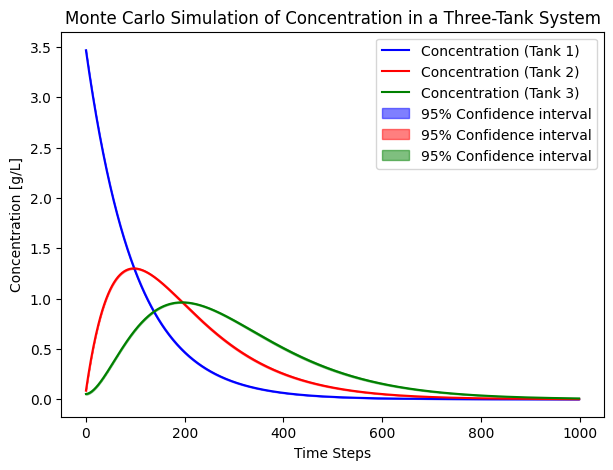

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean[0], color = 'blue', label = 'Concentration (Tank 1)')
plt.plot(time_steps, c_mean[1], color = 'red', label = 'Concentration (Tank 2)')
plt.plot(time_steps, c_mean[2], color = 'green', label = 'Concentration (Tank 3)')
plt.fill_between(time_steps, ci_lower[0], ci_upper[0], alpha = 0.5, color = 'blue', label = "95% Confidence interval")
plt.fill_between(time_steps, ci_lower[1], ci_upper[1], alpha = 0.5, color = 'red', label = "95% Confidence interval")
plt.fill_between(time_steps, ci_lower[2], ci_upper[2], alpha = 0.5, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Simulation of Concentration in a Three-Tank System')
plt.show()

$$\textcolor{red}{\text{Talk about the result. Peak values, steady state? Plot uncertainty?}}$$

## Part 3: Validation Againts ODE Solutions

We have the following system of equations

\begin{align*}
    \frac{dC_1}{dt} =& \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C_1,\\
    \frac{dC_2}{dt} =& \frac{Q_{in}}{V} C_{1} - \frac{Q_{out}}{V} C_2,\\
    \frac{dC_3}{dt} =& \frac{Q_{in}}{V} C_{2} - \frac{Q_{out}}{V} C_3.
\end{align*}

with the given average values

$$V = 1000 \text{ L} \quad Q_{out} = Q_{in} =  100 \text{ L/s} \quad C_{in} = 0.25 \text{ g/L} \quad C_1(0) = 3.5 \text{ g/L} \quad C_2(0) = C_3(0) = 0 \text{ g/L}$$

$$\textcolor{red}{\text{Write about how ODE solver works}}$$

$$\textcolor{red}{\text{Write about making ODE match MC}}$$

In [18]:
from ode_solver import ODESolver

def diff_eqns(c, t):
    ''' 3-tank system '''
    v = 1000
    q_in = q_out = 100
    c_in = 0.25

    c_1, c_2, c_3 = c
    dc = np.zeros(len(c))

    dc[0] = q_in/v * c_in - q_out/v * c_1 #Tank 1
    dc[1] = q_in/v * c_1 - q_out/v * c_2 #Tank 2
    dc[2] = q_in/v * c_2 - q_out/v * c_3 #Tank 3

    return dc

obj = ODESolver(diff_eqns, 0, 100, 0.1, [3.5, 0, 0], 'rk4', adaptive = False)
t_num, c_num = obj.solve()

#Convert physical time to match MC timesteps
t_num = t_num * 10
t_num = t_num[:len(time_steps)]
c_num = c_num[:len(time_steps)]


$$\textcolor{red}{\text{Write something about chaning Cin}\\\text{Change var names}}$$

In [19]:
(c_mean,
 c_std,
 ci_lower,
 ci_upper
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, n_tanks = 3, c_in = 0.25)

### Task 1 

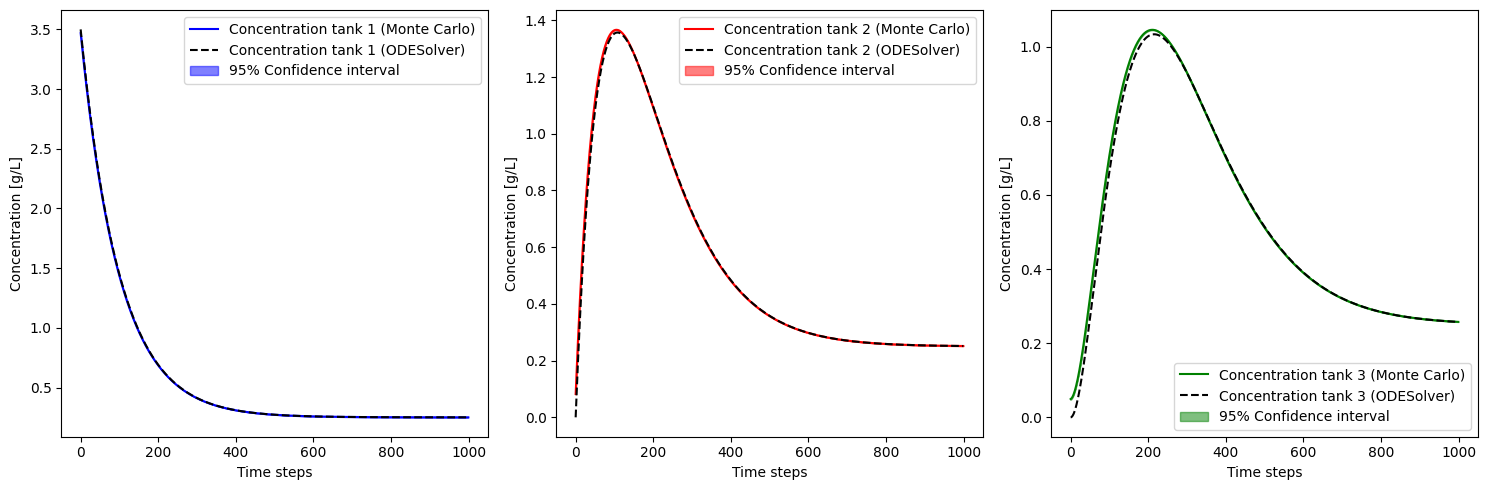

In [21]:
plt.figure(figsize=(15, 5))
colors = ['blue', 'red', 'green']

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(time_steps, c_mean[i], color = colors[i], label = f'Concentration tank {i + 1} (Monte Carlo)')
    plt.plot(t_num, c_num[:, i],'--', color = 'black', label = f'Concentration tank {i + 1} (ODESolver)')
    plt.fill_between(time_steps, ci_lower[i], ci_upper[i], alpha = 0.5, color = colors[i], label = "95% Confidence interval")
    plt.legend()
    plt.ylabel('Concentration [g/L]')
    plt.xlabel('Time steps')

plt.tight_layout()
plt.show()

### Task 2

$$\textcolor{red}{\text{Evaluate accuracy, consistency, and computational efficiency of the stochastic approach}\\\text{maybe find a way to show this numbers, the root-mean-square difference between the MC mean and ODE}}$$

### Task 3

$$\textcolor{red}{\text{Discuss advantages and limitations of Monte Carlo methods versus deterministic ODE solutions.}\\\text{(e.g. “the maximum absolute difference between the MC mean and ODE solution over time is about X g”) or compare CPU time (“the MC simulation took about XX s for 100 runs, whereas the ODE solver took YY s”).}}$$

# Exercise 2: Spreading of contaminants in underground aquifers using random walk

## Part 1: 2D Random Walk Model

### Task 1 - Something

In [13]:
import random
rnd.seed(18)
random.seed(18)

def random_walk_2d_basic(n_steps, start_pos = (1000, 1000), bounds = (0, 2000)):

    #Start position
    x, y = start_pos
    x_path = [x]
    y_path = [y]

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)
    stay = (0, 0)

    directions = [north, south, east, west, stay]

    for _ in range(n_steps):

        #Choose a dicection at randon
        dx, dy = random.choice(directions)

        #Walk
        x += dx
        y += dy

        #Boundary check
        if not (bounds[0] <= x <= bounds[1] and bounds[0] <= y <= bounds[1]):
            break

        x_path.append(x)
        y_path.append(y)

    return x_path, y_path

In [14]:
n_steps = 1000
n_particles = 1000

side = int(np.sqrt(n_particles))  # 31 x 31 ≈ 1000
offset = side // 2

start_pos = [(1000 + i - offset, 1000 + j - offset)
             for i in range(side)
             for j in range(side)]

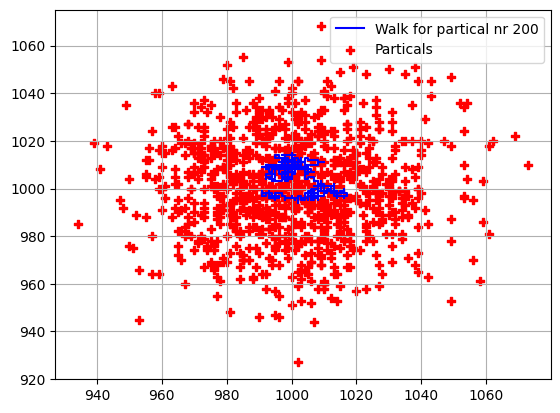

In [15]:
points = []
paths = []

n_steps = 1000
n_particles = 1000

for pos in start_pos:
    x_path, y_path = random_walk_2d_basic(n_steps, pos)
    paths.append((x_path, y_path))
    points.append((x_path[-1], y_path[-1]))

x_coords, y_coords = zip(*points)

#Path of partical 200
x_200, y_200 = paths[200]

#Plotting
plt.plot(x_200, y_200, '-', color = 'blue', label = 'Walk for partical nr 200')
plt.scatter(x_coords, y_coords, marker = 'P', color = 'red', label = 'Particals')
plt.legend()
plt.grid()
plt.show()

In [16]:
def random_walk_2d_weighted(n_steps, start_pos = (1000, 1000), bounds = (0, 2000)):

    #Start position
    x, y = start_pos
    x_path = [x]
    y_path = [y]

    #Directions to choose from (dx, dy)
    north = (0, 1)
    north_west = (-1, 1)
    north_east = (1, 1)
    south = (0, -1)
    south_west = (-1, -1)
    south_east = (1, -1)
    east = (1, 0)
    west = (-1, 0)
    stay = (0, 0)

    directions = [north,
                  north_west,
                  north_east,
                  south,
                  south_west,
                  south_east,
                  east,
                  west,
                  stay]

    probabilities = np.array([0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.2])

    #Make sure sum of prob is 1
    assert np.isclose(probabilities.sum(),1), 'Probabilities must sum to 1'

    for _ in range(n_steps):

        #Choose a dicection at randon
        dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Boundary check
        if not (bounds[0] <= x <= bounds[1] and bounds[0] <= y <= bounds[1]):
            break

        x_path.append(x)
        y_path.append(y)

    return x_path, y_path

In [17]:
points = []
paths = []

n_steps = 1000
n_particles = 1000

for pos in start_pos:
    x_path, y_path = random_walk_2d_weighted(n_steps, pos)
    paths.append((x_path, y_path))
    points.append((x_path[-1], y_path[-1]))

x_coords, y_coords = zip(*points)

#Path of partical 200
x_200, y_200 = paths[200]

#Plotting
plt.plot(x_200, y_200, '-', color = 'blue', label = 'Walk for partical nr 200')
plt.scatter(x_coords, y_coords, marker = 'P', color = 'red', label = 'Particals')
plt.legend()
plt.grid()
plt.show()

KeyboardInterrupt: 

## Part 2: 2D Random Walk Model of Contaminant Transport in Aquifers

### Task 1

In [ ]:
source = (1000, 1000)

### Task 2

In [ ]:
distance_m = 10_000 #meters
migration_rate = 10 #meters/year

minimum_time = distance_m / migration_rate #years

print(f'The minimum time required for the contaminant to reach 10 km is {minimum_time} years')

The minimum time required for the contaminant to reach 10 km is 1000.0 years


### Task 3

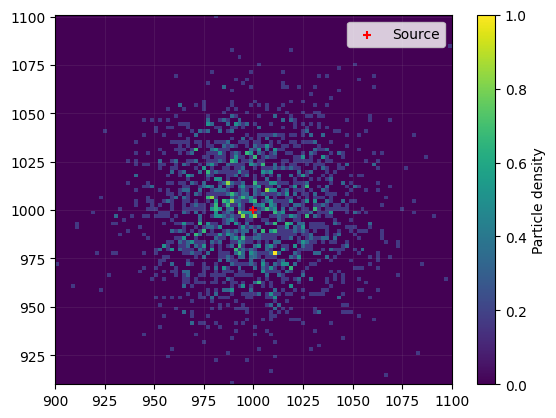

In [ ]:
n_particles = 2000
n_steps = 2000

final_pos = []

for i in range(n_particles):
    x_path, y_path = random_walk_2d_basic(n_steps, source)
    final_pos.append((x_path[-1], y_path[-1]))

final_pos_x, final_pos_y = zip(*final_pos)

#Plotting
plt.hist2d(final_pos_x, final_pos_y, bins=100)
plt.scatter(1000, 1000, color='red', marker='+', label='Source')
plt.colorbar(label="Particle density")
plt.legend()
plt.grid(alpha = 0.1)
plt.show()

### Task 4

In [ ]:
random.seed(67)
def time_to_reach_distance_unbiased(distance_to_reach = 1000, start_pos = (1000, 1000)):
    years = 0

    #To improve computational speed
    distance_to_reach = distance_to_reach**2

    #Start position
    x, y = start_pos

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)

    directions = [north, south, east, west]

    while True:
        #Choose a dicection at randon
        dx, dy = random.choice(directions)

        #Walk
        x += dx
        y += dy

        #Steps
        years += 1

        #See if distance is reached
        distance =(x - start_pos[0])**2 + (y - start_pos[1])**2
        if distance >= distance_to_reach:
            return years


In [ ]:
arrival_times_unbiased = []

n_runs = 100

for i in range(n_runs):
    arrival_times_unbiased.append(time_to_reach_distance_unbiased(1000, (1000, 1000)))

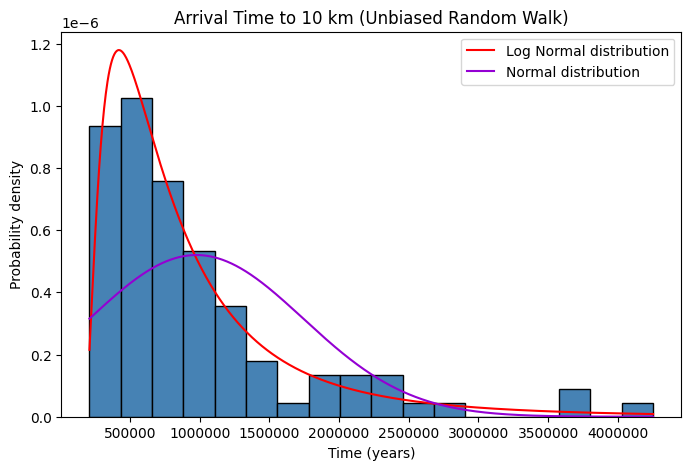

In [ ]:
import scipy.stats as stats
arrival_times_unbiased = np.array(arrival_times_unbiased)
shape, loc, scale = stats.lognorm.fit(arrival_times_unbiased)
mu, sigma = arrival_times_unbiased.mean(), arrival_times_unbiased.std()
x = np.linspace(min(arrival_times_unbiased), max(arrival_times_unbiased), 1000)

plt.figure(figsize=(8, 5))
plt.hist(arrival_times_unbiased, bins=18,density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Unbiased Random Walk)')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color = 'red', label = 'Log Normal distribution')
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Time (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()


### Task 5

In [ ]:
random.seed(18)
def time_to_reach_distance_biased(distance_to_reach = 1000, start_pos = (1000, 1000)):
    years = 0

    #Start position
    x, y = start_pos

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)

    directions = [north, south, east, west]

    probabilities = np.array([0.2,
                              0.4,
                              0.2,
                              0.2])

    #Make sure sum of prob is 1
    assert np.isclose(probabilities.sum(),1), 'Probabilities must sum to 1'

    while True:
        #Choose a dicection at randon
        dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Steps
        years += 1

        #See if distance is reached
        target_y = start_pos[1] - distance_to_reach
        if y <= target_y:
            return years


In [ ]:
arrival_times_biased = []

n_runs = 100

for i in range(n_runs):
    arrival_times_biased.append(time_to_reach_distance_biased(1000, (1000, 1000)))

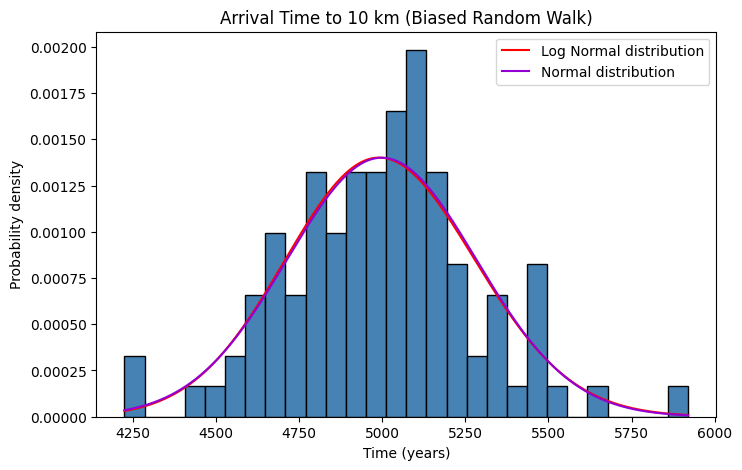

In [ ]:
arrival_times_biased = np.array(arrival_times_biased)
shape, loc, scale = stats.lognorm.fit(arrival_times_biased)
mu, sigma = arrival_times_biased.mean(), arrival_times_biased.std()
x = np.linspace(min(arrival_times_biased), max(arrival_times_biased), 1000)

plt.figure(figsize=(8, 5))
plt.hist(arrival_times_biased, bins=28,density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Biased Random Walk)')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color = 'red', label = 'Log Normal distribution')
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Time (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()